<a href="https://colab.research.google.com/github/isambilo/rML/blob/main/ASSN02_COMPAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open the methodology in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Importing all required libraries
import warnings
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
len(raw_data)

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:

* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# --- Variable groups ---------------------------------------------------------
numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# --- Column selection --------------------------------------------------------
df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# --- Filtering ---------------------------------------------------------------
df = df[
    df["days_b_screening_arrest"].between(-30, 30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
].copy()

# --- Type conversions --------------------------------------------------------
# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Convert non-numeric, non-datetime columns to category
other_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in other_cols:
    df[col] = df[col].astype("category")

# --- Derived categorical variables ------------------------------------------
df["crime_factor"] = df["c_charge_degree"].astype("category")

# Relevel age_cat with "25 - 45" as reference
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45"] +
                                  [c for c in df["age_cat"].unique() if c != "25 - 45"])

# Relevel race with "Caucasian" as reference
df["race_factor"] = pd.Categorical(df["race"], categories=["Caucasian"] +
                                   [c for c in df["race"].unique() if c != "Caucasian"])

# Gender factor with labels Female/Male and reference = Male
df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

# Score factor: LowScore vs HighScore
df["score_factor"] = (df["score_text"] != "Low").astype(int)

# --- Row count ---------------------------------------------------------------
len(df)

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
df["age_cat"].value_counts().to_frame().T

age_cat,25 - 45,Less than 25,Greater than 45
count,3532,1347,1293


In [9]:
df["race"].value_counts().to_frame().T

race,African-American,Caucasian,Hispanic,Other,Asian,Native American
count,3175,2103,509,343,31,11


In [10]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df["score_text"].value_counts().to_frame().T

score_text,Low,Medium,High
count,3421,1607,1144


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df["sex"].value_counts().to_frame().T

sex,Male,Female
count,4997,1175


In [14]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
(df["two_year_recid"] == 1).sum()

np.int64(2809)

In [16]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

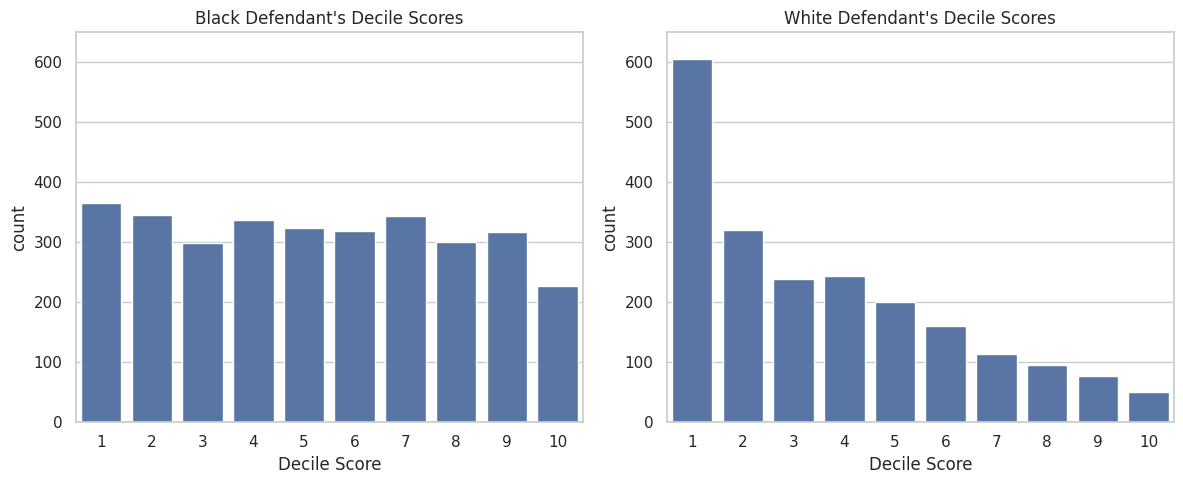

In [17]:
# Set a clean style
sns.set(style="whitegrid")

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Black defendants
sns.countplot(
    data=df[df["race"] == "African-American"],
    x="decile_score",
    order=sorted(df["decile_score"].unique()),
    ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

# White defendants
sns.countplot(
    data=df[df["race"] == "Caucasian"],
    x="decile_score",
    order=sorted(df["decile_score"].unique()),
    ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. Because we've already changed some variables into category type, we'll now run a logistic regression, comparing low scores to high scores.

In [19]:
model_glm = smf.logit(
    "score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

model_glm.summary()

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        05:12:05   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430      0.000      -1.679      -1.372
gender_factor[T.Female]             0.2213      0.080      2.783      0.005       0.065       0.377
age_factor[T.Greater than 45]      -1.3556      0.099    -13.682      0.000      -1.550      -1.161
age_factor[T.Less than 25]          1.3084      0.076     17.232      0.000       1.160       1.457
race_factor[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
race_factor[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
race_factor[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
race_factor[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
race_factor[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
crime_factor[T.M]                  -0.3112      0.067     -4.677      0.000      -0.442      -0.181
two_year_recid[T.1]                 0.6859      0.064     10.713      0.000       0.560       0.811
priors_count                        0.2689      0.011     24.221      0.000       0.247       0.291
===================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
print(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))

1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [21]:
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

Confusion Matrix Building Workflow:

In [23]:
# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)

# Predicted class (0/1 threshold)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, 1, 0)

In [24]:
pred_cat = pd.Categorical(
    df["pred_class"],
    categories=[0, 1],
    ordered=True
)

pred_cat = pred_cat.rename_categories(["No Recid", "Recid"])

df["pred_class"] = pred_cat

In [25]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

# Build confusion matrix
overall_cm = pd.crosstab(
    index=df["pred_class"],       # Predicted
    columns=df["two_year_recid"]  # Actual
)

print(overall_cm)

# Normalize column names to strings for safe indexing
overall_cm.columns = overall_cm.columns.astype(str)

# Extract cells exactly like R
TP = overall_cm.loc["Recid", "1"]
TN = overall_cm.loc["No Recid", "0"]
FP = overall_cm.loc["Recid", "0"]
FN = overall_cm.loc["No Recid", "1"]
n  = overall_cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall    = TP / (TP + FN) if (TP + FN) > 0 else np.nan
fpr       = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr       = FN / (FN + TP) if (FN + TP) > 0 else np.nan

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

two_year_recid     0     1
pred_class                
No Recid        2653   945
Recid            710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [26]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

# Create actual and pred columns (mutate equivalent)
df["actual"] = df["two_year_recid"].astype(int)
df["pred"]   = (df["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df.groupby("race")
      .apply(lambda g: pd.Series({
          "n": len(g),
          "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
          "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
          "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
          "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
      }))
      .reset_index()
)

# Compute derived metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort like R's arrange(desc(n))
race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


FPR and FNR Disparity by Race.

In [27]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

# Select needed columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get Caucasian reference values
ref_FPR = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
ref_FNR = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - ref_FPR).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - ref_FNR).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


# ============ START ASSIGNMENT 2 ===============

## Explaining the COMPAS Replacement Model

For the next analysis, the same features and target variables from the logistic function will be used.

Let's begin with creating our Train and Test sets.

Loading Required Libraries

In [28]:
!pip install lime # install if necessary
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (confusion_matrix, accuracy_score,roc_auc_score)
from lime.lime_tabular import LimeTabularExplainer

In [29]:
# X and y from the cleaned COMPAS cohort (Lecture 01)
X = df[["gender_factor", "age_factor", "race_factor", "priors_count", "crime_factor", "two_year_recid"]]
y = df["score_factor"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


Fitting logistic regression and gradient-boosted tree

In [30]:
# numeric_features & category_features as in Lecture 01.
preprocessor = ColumnTransformer([
("num", StandardScaler(), ["priors_count", "two_year_recid"]
),
("cat", OneHotEncoder(
handle_unknown="ignore"),
 ["gender_factor", "age_factor", "race_factor", "crime_factor"]),
])
# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([("preprocessor", preprocessor),
("classifier", LogisticRegression(max_iter=1000,
random_state=42))
])
lr_pipeline.fit(X_train, y_train)
# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
("preprocessor", preprocessor),
("classifier", GradientBoostingClassifier(
n_estimators=200,
max_depth=4,
random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

Compare model performance by race.

In [31]:
def group_metrics(pipeline, X, y, group_col="race_factor"):
  results = []
  X_ = X.copy()
  X_["actual"] = y.values
  X_["pred"] = pipeline.predict(X)
  X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
  for group, gdf in X_.groupby(group_col):
    tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()
    results.append({
        "race" : group,
        "n" : len(gdf), "accuracy" : round(accuracy_score(
            gdf["actual"], gdf["pred"]), 3),
        "FPR" : round(fp / (fp + tn), 3),
        "FNR" : round(fn / (fn + tp), 3),
        "AUC" : round(roc_auc_score(
            gdf["actual"],
            gdf["pred_prob"]), 3),
        })
  return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
1             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
1             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


LIME explanations: Black vs White defendant

In [32]:
X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (["priors_count", "two_year_recid"] + list(
            preprocessor.named_transformers_["cat"].get_feature_names_out(
                ["gender_factor", "age_factor", "race_factor", "crime_factor"]))),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous= True,
    random_state = 42
    )

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob
black_idx = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob").index[
    len(X_test_copy[X_test_copy["race_factor"] == "African-American"]) // 2
]

white_idx = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob").index[
    len(X_test_copy[X_test_copy["race_factor"] == "Caucasian"]) // 2
]
# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),("White defendant", white_idx)]:
  row_enc = preprocessor.transform(X_test.loc[[idx]])
  exp = explainer.explain_instance(
      data_row = row_enc[0],
      predict_fn= gbt_pipeline["classifier"].predict_proba,num_features=6
)
  print(f"\n LIME: {label} ")
  print(f"Predicted probability: "f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
  for feat, weight in exp.as_list():
    print(f"{feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.594
age_factor_Less than 25 <= 0.00          -0.3523
age_factor_Greater than 45 <= 0.00       +0.2269
0.00 < race_factor_African-American <= 1.00 +0.0941
-0.92 < two_year_recid <= 1.09           +0.0936
race_factor_Hispanic <= 0.00             +0.0928
-0.47 < priors_count <= 0.17             -0.0901

 LIME: White defendant 
Predicted probability: 0.241
race_factor_Native American <= 0.00      -0.4254
age_factor_Less than 25 <= 0.00          -0.3536
-0.68 < priors_count <= -0.47            -0.2688
age_factor_Greater than 45 <= 0.00       +0.2243
race_factor_African-American <= 0.00     -0.1051
two_year_recid <= -0.92                  -0.0860


SHAP beeswarm and waterfall: Black vs White

**Note:**

The masker line was removed because it triggered SHAP’s additivity error when paired with a tree model trained on an already‑encoded feature matrix. The masker-based API expects raw features and a full pipeline, so the explainer couldn’t reconcile its baseline with the model’s output. Switching to the classic `TreeExplainer` avoids this mismatch and produces valid SHAP values without changing the model or preprocessing.


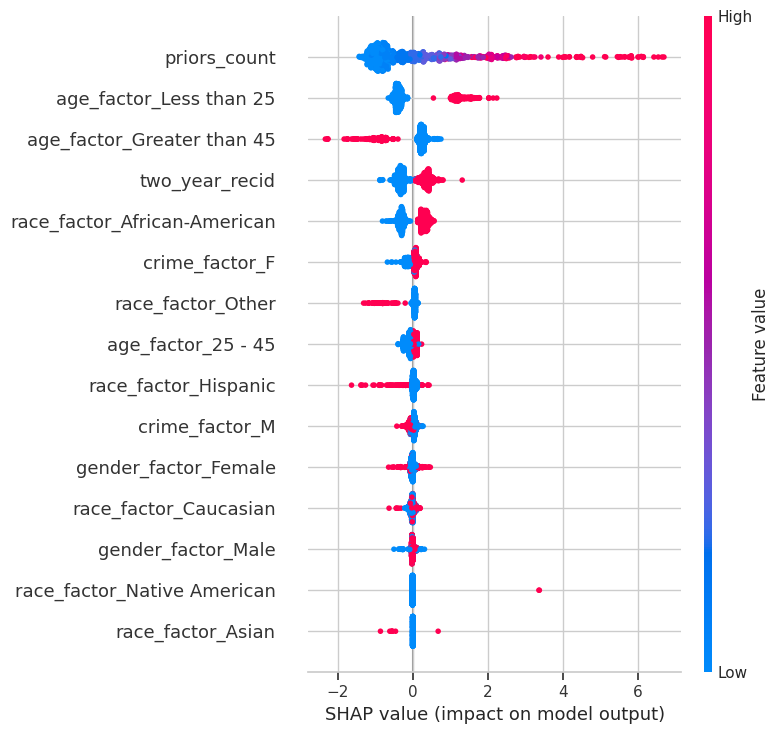

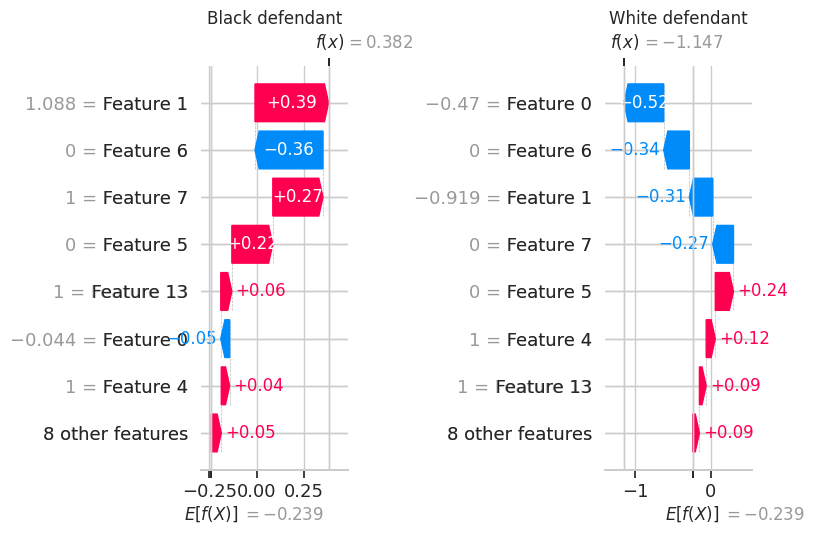

In [33]:
!pip install shap # install if necessary
import shap

X_test_enc = preprocessor.transform(X_test)
feat_names = (["priors_count", "two_year_recid"] +
list(preprocessor.named_transformers_["cat"].get_feature_names_out(
    ["gender_factor", "age_factor", "race_factor", "crime_factor"])))
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"]
    )
shap_values = explainer_shap(X_test_enc)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
feature_names=feat_names)

# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
     (axes[1], white_loc, "White defendant")]:
     plt.sca(ax)
     shap.waterfall_plot(shap_values[loc],
max_display=8,show=False)
     ax.set_title(label)

plt.tight_layout()
plt.show()

Counterfactuals with DiCE: Black vs White

In [34]:
X_train["two_year_recid"] = pd.to_numeric(X_train["two_year_recid"])
X_test["two_year_recid"] = pd.to_numeric(X_test["two_year_recid"])

In [35]:
!pip install dice-ml #install if necessary
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = ["priors_count", "two_year_recid"],
    outcome_name = "score_factor"
    )
dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
    )
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [
    ("Black defendant", black_idx),
     ("White defendant", white_idx)
     ]:
     query = X_test.loc[[idx]]
     cf = exp_dice.generate_counterfactuals(
         query,
         total_CFs = 3,
         desired_class = "opposite",
         permitted_range = {
             "age_factor" : ["Less than 25", "25 - 45", "Greater than 45"],
                            "priors_count": [0, 38]
                            },
         features_to_vary = ["age_factor", "priors_count",
                             "crime_factor"]
         )
print(f"\n DiCE counterfactuals: {label} ")
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.94it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,Male,25 - 45,Caucasian,1,F,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,-,-,-,26,-,-,1
1,-,-,-,19,-,-,1
2,-,-,-,22,-,-,1


**Governance memo on COMPAS model explanations**

This memo summarizes findings from SHAP, LIME, and DiCE analyses of the COMPAS replacement model looking at transparency, fairness, and how well it works in court settings. Across all methods, the model shows strong dependence on three factors: `priors_count`, `age_factor`, and `two_year_recid`. SHAP results indicate that younger defendants, particularly those in the “Less than 25” group, receive substantially higher risk contributions, while older defendants receive strong negative contributions. Waterfall plots for the highest‑ and lowest‑risk individuals in each racial group show that Black defendants often accumulate larger positive contributions from age and priors than White defendants with similar profiles, showing disparities observed in false‑positive and false‑negative rates.

LIME explanations for the same individuals generally agree with SHAP on the importance of priors and age but display greater variability in feature weighting. This instability reflects LIME’s sensitivity to local perturbations and highlights the governance risk of relying on a single explanation method. Divergence between SHAP and LIME underligns the need for multi‑method oversight to avoid over‑interpreting any one explanation.

DiCE counterfactuals were generated for each individual to identify the minimal changes required to flip predictions. The model groups age into categories, so counterfactuals can only show changes between those brackets, not small, gradual age shifts. Most of the counterfactual scenarios involved lowering `priors_count` or moving into a higher age group. It tends to favor older brackets when trying to reduce risk scores. None required changes to immutable features such as race or sex, consistent with ethical constraints.

Monitoring should happen regularly with checks on racial differences in error rates, stability comparisons between SHAP and LIME explanations, and repeated counterfactual testing after any update. A governance process combining statistical fairness measures with explanation-based diagnostics is probably best for maintaining transparency, stability, and compliance with judicial fairness norms. This approach helps keep the model aligned with real-world outcomes over time.


**NOTE**

***We maintained the original workflow established in Assignment 1 by preserving the categorical representation of age throughout the entire modeling and audit process. The initial COMPAS analysis intentionally transformed raw age into three discrete brackets—“Less than 25,” “25–45,” and “Greater than 45”—to mirror the structure used in the ProPublica audit and to ensure interpretability across logistic regression, fairness metrics, and model explanations. Reverting to a continuous age variable at the counterfactual stage would have required retraining the model, rebuilding the preprocessing pipeline, and re running all interpretability and fairness analyses. More importantly, it would have produced results that were inconsistent with the original COMPAS audit framework, undermining the comparability and coherence of the entire workflow. By keeping age in its categorical form, we ensured that SHAP, LIME, and DiCE all operated on the same feature space, preserving methodological integrity and allowing the explanations to reflect the model’s true decision logic.***